In [1]:
from rashomon_importance_distribution import RashomonImportanceDistribution
import pandas as pd
import numpy as np

# Prepare a binarized dataset, with the rightmost column containing labels
df = pd.read_csv('./monk_1_example_data.csv')

# Specify the mapping used to go from columns in the original dataset
# to binarized columns
mapping={
    0: [0, 1, 2],
    1: [3, 4, 5],
    2: [6, 7],
    3: [8, 9, 10],
    4: [11, 12, 13, 14],
    5: [15, 16]
}

In [91]:
raw_df = pd.read_csv('./rid_gpt.csv')
#removee column q_src, q_tgt, a_src, a_tgt from raw_df
#source_sentence_count and target_sentence_count did not provide useful information
#single source_lang, source syllables and source wiki size were not useful
#raw_df = raw_df.drop(columns=['q_id','q_src', 'q_tgt', 'a_src', 'a_tgt', 'source_sentence_count', 'target_sentence_count',
#                              'source_syllables', 'source_wiki_size', 'source_lang']) 
#put correct_target as the last column

if 'Unnamed: 0' in raw_df.columns:
    raw_df = raw_df.drop(columns=['Unnamed: 0'])

#save the csv
raw_df.head(3)

,sourceMDD>targetMDD,is_q_topic_history,is_q_topic_tech,is_q_type_date_time,cooc_unseen_keywords_ratio_w10,cooc_unseen_keywords_ratio_w50,correct_target
0,True,False,False,False,0.0,0.0,True
1,True,True,False,False,0.0,0.0,False
2,True,False,False,False,0.0,0.0,False


In [93]:
#print the counts in column cooc_unseen_keywords_ratio_w10
print(raw_df['cooc_unseen_keywords_ratio_w10'].value_counts())

cooc_unseen_keywords_ratio_w10
0.000000    273
0.125000     22
0.076923     13
0.166667     12
0.111111     12
0.142857     12
0.100000     11
0.058824      9
0.083333      9
0.090909      9
0.250000      8
0.066667      7
0.200000      7
0.181818      6
0.050000      6
0.222222      5
0.062500      5
0.055556      5
0.071429      4
0.214286      4
0.285714      3
0.047619      3
0.037037      2
0.052632      2
0.333333      2
0.150000      2
0.028571      1
0.307692      1
0.444444      1
0.133333      1
0.360000      1
0.153846      1
0.045455      1
0.040000      1
0.080000      1
0.107143      1
0.172414      1
0.041667      1
0.157895      1
0.103448      1
0.117647      1
Name: count, dtype: int64


In [71]:
raw_df['cooc_unseen_keywords_ratio_w50_zero'] = raw_df['cooc_unseen_keywords_ratio_w50'] == 0.0
raw_df = raw_df.drop(columns=['cooc_unseen_keywords_ratio_w50'])

#print the counts in column cooc_unseen_keywords_ratio_w50
print(raw_df['cooc_unseen_keywords_ratio_w50_zero'].value_counts())

raw_df['cooc_unseen_keywords_ratio_w10_zero'] = raw_df['cooc_unseen_keywords_ratio_w10'] == 0.0
raw_df = raw_df.drop(columns=['cooc_unseen_keywords_ratio_w10'])
print(raw_df['cooc_unseen_keywords_ratio_w10_zero'].value_counts())

#put labels as the last column
correct_target = raw_df.pop('correct_target')
raw_df['correct_target'] = correct_target

raw_df.to_csv('./rid_gemini_processed.csv', index=False)
raw_df.head(3)


cooc_unseen_keywords_ratio_w50_zero
True     284
False    184
Name: count, dtype: int64
cooc_unseen_keywords_ratio_w10_zero
True     273
False    195
Name: count, dtype: int64


,sourceMDD>targetMDD,is_q_topic_history,is_q_topic_tech,is_q_type_date_time,cooc_unseen_keywords_ratio_w50_zero,cooc_unseen_keywords_ratio_w10_zero,correct_target
0,True,False,False,False,True,True,True
1,True,True,False,False,True,True,False
2,True,False,False,False,True,True,False


In [72]:
#remove all comlumns with column name containing 'cooc'
raw_df = raw_df.loc[:, ~raw_df.columns.str.contains('cooc')]
raw_df.head(3)
raw_df.to_csv('./rid_gemini_processed_no_cooc.csv', index=False)

In [73]:
df = pd.read_csv("./rid_gemini_processed.csv")

# Assume last column is the label (target)
label_col = df.columns[-1]
y = df[label_col]
X = df.iloc[:, :-1]  # all feature columns

# ===== 1. Identify feature types =====
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
object_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
boolean_cols = X.select_dtypes(include=["bool"]).columns.tolist()

categorical_cols = []        # will include object + small-unique-count numeric
binary_numeric_cols = []     # truly numeric binary 0/1
continuous_numeric_cols = [] # numeric with many unique values

print("Initial numeric columns:", numeric_cols)
print("Initial object columns:", object_cols)
print("Initial boolean columns:", boolean_cols)

# First, all object/category columns are categorical
categorical_cols.extend(object_cols)
binary_numeric_cols = boolean_cols.copy()  # treat booleans as binary numeric

# Now handle numeric columns
for col in numeric_cols:
    unique_vals = X[col].dropna().unique()
    num_unique = len(unique_vals)

    if num_unique <= 2:
        # Truly binary numeric feature
        binary_numeric_cols.append(col)

    elif num_unique < 5:
        # Numeric but small number of categories -> treat as categorical
        categorical_cols.append(col)

    else:
        # Proper continuous variable
        continuous_numeric_cols.append(col)

print("\n=== Final Column Classification ===")
print("Binary numeric columns:", binary_numeric_cols)
print("Categorical columns:", categorical_cols)
print("Continuous numeric columns:", continuous_numeric_cols)

# ===== 2. Process columns =====

# 2a. Binary numeric: keep as-is (0/1 or similar)
X_binary = X[binary_numeric_cols].copy()

# 2b. Continuous numeric: bin then one-hot encode
# You can adjust n_bins as needed.
n_bins = 4

continuous_dummies_list = []
for col in continuous_numeric_cols:
    # Use quantile-based bins; duplicates='drop' avoids errors if not enough unique values
    binned = pd.qcut(X[col], q=n_bins, duplicates='drop')
    dummies = pd.get_dummies(binned, prefix=col)
    continuous_dummies_list.append(dummies)

X_continuous = pd.concat(continuous_dummies_list, axis=1) if continuous_dummies_list else pd.DataFrame(index=X.index)

# 2c. Categorical: one-hot encode all categories
if categorical_cols:
    # Force these columns to 'category' dtype so get_dummies encodes ALL of them
    X_cat_for_dummies = X[categorical_cols].astype("category")
    # Let pandas choose the prefix = column name (so new cols look like 'col_val')
    X_categorical = pd.get_dummies(X_cat_for_dummies)
else:
    X_categorical = pd.DataFrame(index=X.index)

# ===== 3. Combine all processed features =====
X_processed = pd.concat([X_binary, X_continuous, X_categorical], axis=1)

# Append label as last column (as required by RID)
df_processed = pd.concat([X_processed, y], axis=1)

binning_map = {}
binning_map_names = {}

processed_feature_cols = df_processed.columns[:-1]  # exclude label
processed_col_index = {col: i for i, col in enumerate(processed_feature_cols)}

original_feature_names = X.columns.tolist()

for orig_idx, orig_name in enumerate(original_feature_names):
    if orig_name in binary_numeric_cols:
        new_cols = [orig_name]
    else:
        prefix = f"{orig_name}_"
        new_cols = [c for c in processed_feature_cols if c.startswith(prefix)]

    # Map to indices
    new_indices = [processed_col_index[c] for c in new_cols]

    binning_map[orig_idx] = new_indices
    binning_map_names[orig_name] = new_cols

print("\nProcessed dataframe shape:", df_processed.shape)
print("Label column (last):", label_col)
print("\nExample binning_map entry (index-based):")
for k in list(binning_map.keys())[:5]:
    print(f"Original feature index {k} ({original_feature_names[k]}): new column indices {binning_map[k]}")

print("\nName-based binning_map (for debugging):")
for k in list(binning_map_names.keys())[:6]:
    print(f"{k} -> {binning_map_names[k]}")

# Optionally save outputs
df_processed.to_csv("df_processed_for_RID_no_coco.csv", index=False)

print("Number of features before processing:", X.shape[1])
print("Number of features after processing:", df_processed.shape[1] - 1)  # exclude label

Initial numeric columns: []
Initial object columns: []
Initial boolean columns: ['sourceMDD>targetMDD', 'is_q_topic_history', 'is_q_topic_tech', 'is_q_type_date_time', 'cooc_unseen_keywords_ratio_w50_zero', 'cooc_unseen_keywords_ratio_w10_zero']

=== Final Column Classification ===
Binary numeric columns: ['sourceMDD>targetMDD', 'is_q_topic_history', 'is_q_topic_tech', 'is_q_type_date_time', 'cooc_unseen_keywords_ratio_w50_zero', 'cooc_unseen_keywords_ratio_w10_zero']
Categorical columns: []
Continuous numeric columns: []

Processed dataframe shape: (468, 7)
Label column (last): correct_target

Example binning_map entry (index-based):
Original feature index 0 (sourceMDD>targetMDD): new column indices [0]
Original feature index 1 (is_q_topic_history): new column indices [1]
Original feature index 2 (is_q_topic_tech): new column indices [2]
Original feature index 3 (is_q_type_date_time): new column indices [3]
Original feature index 4 (cooc_unseen_keywords_ratio_w50_zero): new column ind

In [74]:
binning_map

{0: [0], 1: [1], 2: [2], 3: [3], 4: [4], 5: [5]}

In [75]:
# Construct the Rashomon Importance Distribution for this dataset
RID = RashomonImportanceDistribution(
    input_df=df_processed,
    binning_map=binning_map,
    db=5, 
    lam=0.05, 
    eps=0.25,
    vi_metric='sub_mr',
    dataset_name='rid_new_features_6',
    n_resamples=10,
    verbose=True,
    max_par_for_gosdt=5,
    allow_binarize_internally = False
)

0
0
0
Using configuration: {
  "balance": false,
  "cancellation": true,
  "continuous_feature_exchange": false,
  "costs": "",
  "covered_sets_thresholds": [],
  "datatset_encoding": "",
  "depth_budget": 5,
  "diagnostics": true,
  "feature_exchange": false,
  "feature_transform": true,
  "look_ahead": true,
  "memory_checkpoints": [],
  "minimum_captured_points": 0,
  "model": "",
  "model_limit": 10000,
  "non_binary": false,
  "output_accuracy_model_set": false,
  "output_covered_sets": [],
  "precision_limit": 0,
  "profile": "",
  "rashomon": true,
  "rashomon_bound": 0.0,
  "rashomon_bound_adder": 0.25,
  "rashomon_bound_multiplier": 0.0,
  "rashomon_ignore_trivial_extensions": true,
  "rashomon_model": "",
  "rashomon_model_set_suffix": "_bootstrap_1_eps_0.25_db_5_reg_0.05.json",
  "rashomon_trie": "./cached_files/rid_new_features_6/rashomon_outputs/trie_bootstrap_1_eps_0.25_db_5_reg_0.05.json",
  "regularization": 0.05000000074505806,
  "rule_list": false,
  "similar_support"

In [78]:
# Compute the box and whiskers range for each variable
for v in range(df_processed.shape[1] - 1):  # exclude label
    print(f"Variable {v} --------------, Name: {df_processed.columns[v]}")
    
    # Get box and whiskers range for variable
    print("Box and whiskers range:", RID.bwr(v))
    print("Median value:", RID.median(v))
    print("Mean value:", RID.mean(v))

Variable 0 --------------, Name: sourceMDD>targetMDD
Box and whiskers range: (-0.10673076923076907, 0.2137820512820512)
Median value: 0.06923076923076932
Mean value: 0.0584188742080351
Variable 1 --------------, Name: is_q_topic_history
Box and whiskers range: (-0.07467948717948714, 0.12446581196581219)
Median value: 0.026709401709401837
Mean value: 0.02925200333941541
Variable 2 --------------, Name: is_q_topic_tech
Box and whiskers range: (-2.3592239273284576e-16, 3.191891195797325e-16)
Median value: 1.1102230246251565e-16
Mean value: 4.163336342344337e-17
Variable 3 --------------, Name: is_q_type_date_time
Box and whiskers range: (-0.029166666666667174, 0.04861111111111166)
Median value: 1.1102230246251565e-16
Mean value: 0.009251445516110172
Variable 4 --------------, Name: cooc_unseen_keywords_ratio_w50_zero
Box and whiskers range: (-0.05416666666666681, 0.09027777777777801)
Median value: 0.002777777777777879
Mean value: 0.021023607007097316
Variable 5 --------------, Name: cooc_

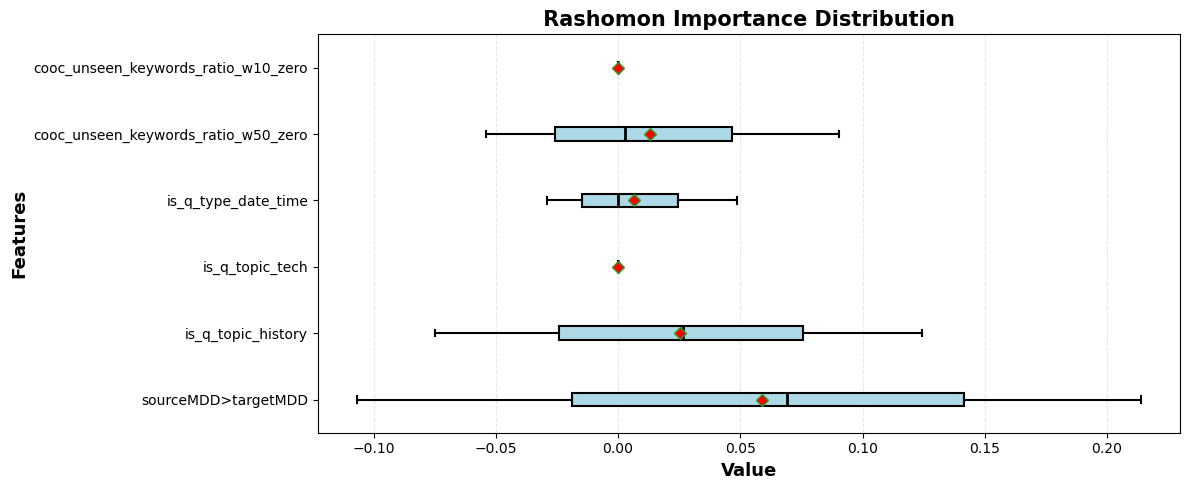

In [95]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))

# Prepare data
box_data = []
labels = []
for v in range(df_processed.shape[1] - 1):
    bw_range = RID.bwr(v)
    box_data.append([bw_range[0], RID.median(v), bw_range[1]])
    labels.append(df_processed.columns[v])

# Horizontal boxplot
bp = ax.boxplot(box_data, labels=labels, vert=False,  # ← Horizontal!
                patch_artist=True,
                widths=0.2,
                showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6),
                medianprops=dict(color='black', linewidth=2),
                boxprops=dict(facecolor='lightblue', edgecolor='black', linewidth=1.5),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5))

ax.set_xlabel('Value', fontsize=13, fontweight='bold')
ax.set_ylabel('Features', fontsize=13, fontweight='bold')
ax.set_title(' Rashomon Importance Distribution ', fontsize=15, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()